# Imports

In [1]:
import os
import sys

In [2]:
current_dir =  os.getcwd()
# replace this following line in the path your frank2d files are.
parent_dir = os.path.abspath(os.path.join(current_dir, os.pardir))
sys.path.append(parent_dir)

In [3]:
parent_dir

'/Users/mariajmelladot/Desktop/Frank2D/6_Frank2D_Oficial/frank2d'

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import time

In [5]:
# frank2d
from frank2d import Frank2D
from frank2d.geometry import Geometry
from frank2d.plot import Plot
from frank2d.posterior_optimization import *
from frank2d.constants import rad_to_arcsec, deg_to_rad

In [6]:
# Huang 2018 
AS209 = {'inc': 34.97, 'pa': 85.76, 'dra':1.9e-3, 'ddec':-2.5e-3, 'rout': 1.2*2, 'disk_name': 'AS209'}
IMLup = {'inc': 47.5, 'pa': 144.5, 'dra':-1.5e-3, 'ddec':1e-3, 'rout': 1.71*2, 'disk_name': 'IMLup'}
Elias27 = {'inc': 56.2, 'pa': 118.8, 'dra':-5e-3, 'ddec':-8e-3, 'rout': 1.88*2, 'disk_name': 'Elias27'}
Elias24 = {'inc': 29, 'pa': 45.7, 'dra':110.8e-3, 'ddec':-386.8e-3, 'rout': 1.03*2, 'disk_name': 'Elias24'}
HD163296 = {'inc':46.7, 'pa':133.33, 'dra':-2.8e-3, 'ddec':7.7e-3, 'rout':1.7*2, 'disk_name': 'HD163296' }
HD143006 = {'inc': 18.6, 'pa': 169, 'dra':-5.9e-3, 'ddec':21.7e-3, 'rout': 0.518*3, 'disk_name': 'HD143006'}

In [7]:
def f2d(data):
    dir = "/Users/mariajmelladot/Desktop/Frank2D/data/uvtables/"
    disk_name = data['disk_name']
    data_file = dir +"uvtable_" + disk_name + "_continuum.npz"
    
    inc = data['inc']
    pa = data['pa']
    dra = data['dra']
    ddec = data['ddec']
    rout = data['rout']

    # Frank Parameters
    N = 300
    
    # Load data
    file = np.load(data_file)
    u, v, Re, Im, Weights = file['u'], file['v'], file['Re'], file['Im'], file['w']
    Vis = Re + Im*1j
    
    uvtable = {'u': u, 'v': v, 'vis': Vis, 'weights': Weights }

    dir_fits =  "/Users/mariajmelladot/Desktop/Frank2D/data/fits/"
    disk_fits = disk_name + '_continuum.fits'
    fits_file = dir_fits + disk_fits

    geom = Geometry(inc, pa, dra, ddec)
    frank2d = Frank2D(N, rout, geom)
    
    return frank2d, geom, uvtable, fits_file

# AS209

In [8]:
f2d_AS209, geom_AS209, uvtable_AS209, fits_1mm_AS209 = f2d(AS209)

In [9]:
f2d_AS209.process_vis(uvtable_AS209)

Shifted grid..
Setting gridded data...


Setting GP Kernel Wendland...
Creating sparse linear system...
--> time kernel = 0.06  min |  3.53 seconds
--> time loop = 0.00  min |  0.13 seconds
--> time = 0.06  min |  3.67 seconds
Solving linear system...
         * rtol: 1e-08
         * final tolerance: 2.881751982790495
Final tolerance :  2.881751982790495
.... iteration:  0
                        -> actual tol:  288175198.2790495 vs  2.881751982790495
.... iteration:  1
                        -> actual tol:  39773051.282940544 vs  2.881751982790495
.... iteration:  2
                        -> actual tol:  30605898.285020255 vs  2.881751982790495
.... iteration:  3
                        -> actual tol:  31458951.244836483 vs  2.881751982790495
.... iteration:  4
                        -> actual tol:  32660086.132000692 vs  2.881751982790495
.... iteration:  5
                        -> actual tol:  32037725.273025826 vs  2.881751982790495
.... iteration:  6
                        -> actual tol:  68809248.88808325 vs  2.8

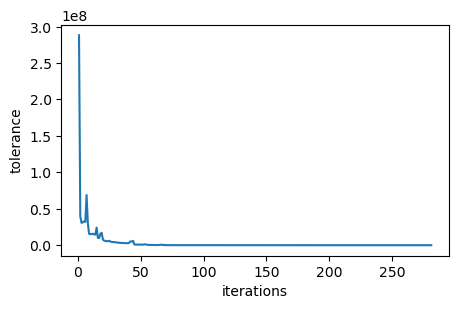

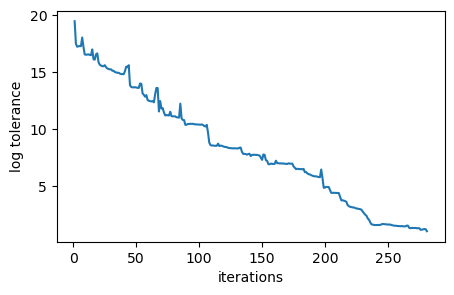

--> time = 0.19  min |  11.62 seconds
-> CGM converged?   True
-> Fit correctly?   True
!!!!  Sucess  !!!!
Building full visibility model...


In [10]:
#start_time = time.time()

params_AS209 =  {'m': -2, 'c': 1e8, 'l': 7e4}
#f2d_AS209.fit(u = uvtable_AS209['u'], v = uvtable_AS209['v'], Vis = uvtable_AS209['vis'], Weights = uvtable_AS209['weights'], 
f2d_AS209.fit(kernel_params = params_AS209, rtol = 1e-8 )

#end_time = time.time()
#print(f"F2D model in {(end_time - start_time)/60:.2f} minutes | {(end_time - start_time):.2f} seconds.")

### Plot

In [11]:
Plot_AS209 = Plot(f2d_AS209, geom_AS209)

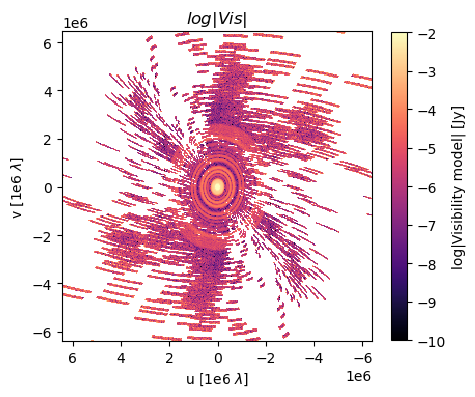

In [12]:
Plot_AS209.visibility(fig_size = 5, kind = 'input')

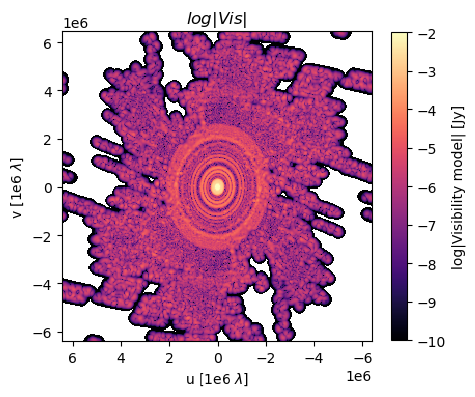

In [13]:
Plot_AS209.visibility(fig_size = 5)

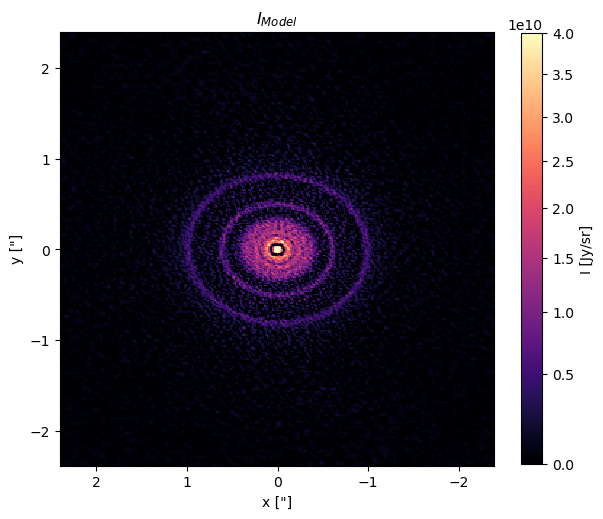

In [14]:
Plot_AS209.intensity(fig_size = 7, vmax = 4e10, gamma = 0.75)

Performing 1D Frank fit...


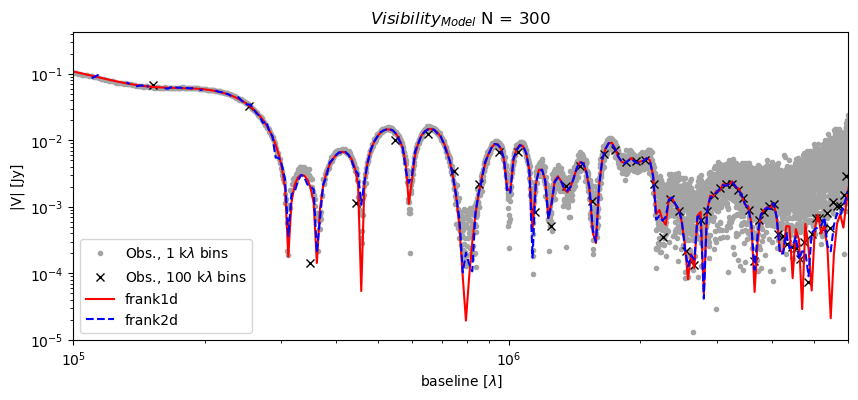

In [13]:
Plot_AS209.visibility_profile(input = uvtable_AS209, weighted = True, frank1d = True)

Performing 1D Frank fit...


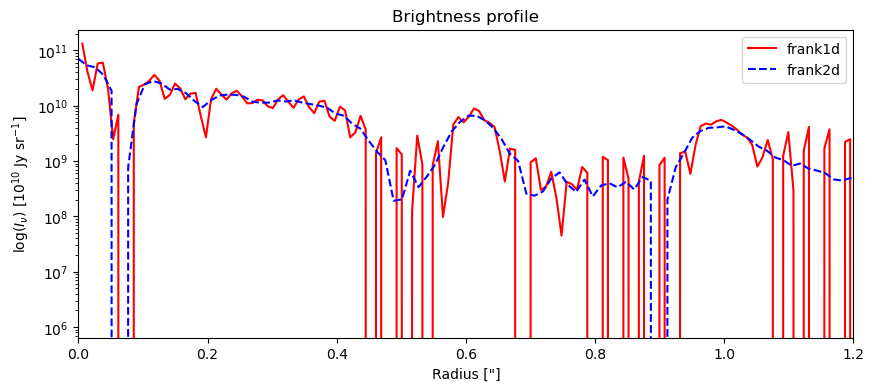

In [14]:
Plot_AS209.intensity_profile(clean = False, fits_file = fits_1mm_AS209)

	 Reverting to standard azimuthal averaging; will ignore `unit` argument.
Clean beam: 0.038216292858108 x 0.036224924027904 arcsec
Performing 1D Frank fit...


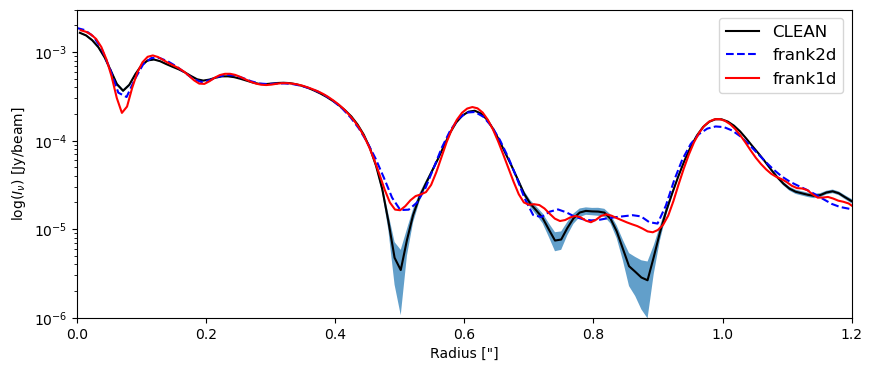

In [57]:
Plot_AS209.intensity_profile(clean = True, fits_file = fits_1mm_AS209)

In [ ]:
Plot_AS209.intensity_profile(clean = True, fits_file = fits_1mm_AS209)

### Best

In [15]:
f2d_AS209.search_MAP()

Optimizing the posterior distribution...
-->  3.43 seconds for -logP(param|data) 
------> p: -2.000, m: -2.000, logc: 8.000000e+00, logl: 4.000000e+00: -4868.31 (jDj=-2.978e+02, |S|=-1.003e+04, |D|=-4.003e-01)
-->  3.49 seconds for -logP(param|data) 
------> p: -2.000, m: -2.000, logc: 8.000000e+00, logl: 4.000000e+00: -4868.31 (jDj=-2.978e+02, |S|=-1.003e+04, |D|=-4.003e-01)
-->  3.51 seconds for -logP(param|data) 
------> p: -1.900, m: -2.000, logc: 8.100000e+00, logl: 4.000000e+00: -4620.15 (jDj=-2.185e+02, |S|=-9.459e+03, |D|=-3.171e-01)
-->  3.24 seconds for -logP(param|data) 
------> p: -2.162, m: -2.000, logc: 7.838197e+00, logl: 4.000000e+00: -5246.97 (jDj=-4.717e+02, |S|=-1.097e+04, |D|=-5.829e-01)
-->  3.13 seconds for -logP(param|data) 
------> p: -4.247, m: -2.000, logc: 5.752511e+00, logl: 4.000000e+00: 22016.02 (jDj=-6.693e+04, |S|=-2.297e+04, |D|=-6.948e+01)
-->  3.27 seconds for -logP(param|data) 
------> p: -2.958, m: -2.000, logc: 7.041536e+00, logl: 4.000000e+00: -60

In [62]:
best_AS209 = f2d_AS209.MAP
best_AS209

{'m': -1.3620942401288272, 'c': 4681.245509195992, 'l': 72454.18892316935}

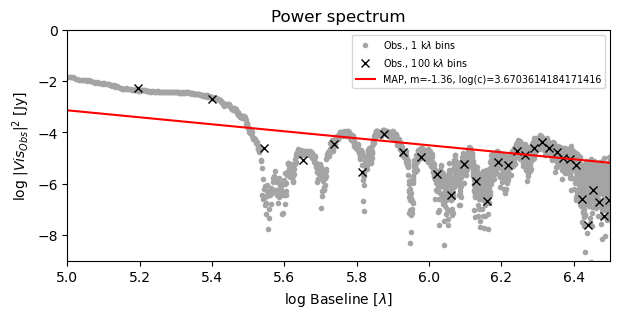

In [67]:
f2d_AS209.PP.plot_MAP_power_spectrum( uvtable_AS209['u'], uvtable_AS209['v'],
                                      uvtable_AS209['vis'], uvtable_AS209['weights'])

Setting GP Kernel Wendland...
Creating sparse linear system...
--> time = 0.10  min |  6.04 seconds
Solving linear system...
         * rtol: 1e-08
         * final tolerance: 2.881751982790495
Final tolerance :  2.881751982790495
.... iteration:  0
                        -> actual tol:  288175198.2790495 vs  2.881751982790495
.... iteration:  1
                        -> actual tol:  26326029.400635004 vs  2.881751982790495
.... iteration:  2
                        -> actual tol:  23214280.628287163 vs  2.881751982790495
.... iteration:  3
                        -> actual tol:  23233701.207801204 vs  2.881751982790495
.... iteration:  4
                        -> actual tol:  23003288.59707105 vs  2.881751982790495
.... iteration:  5
                        -> actual tol:  22241997.23544606 vs  2.881751982790495
.... iteration:  6
                        -> actual tol:  23862398.663001567 vs  2.881751982790495
.... iteration:  7
                        -> actual tol:  23494428.4381

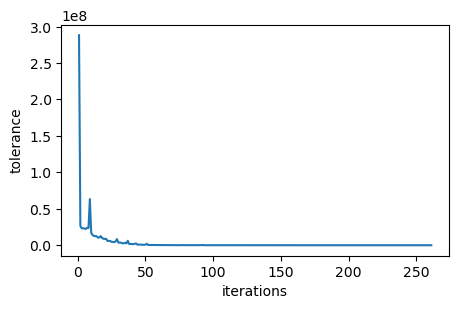

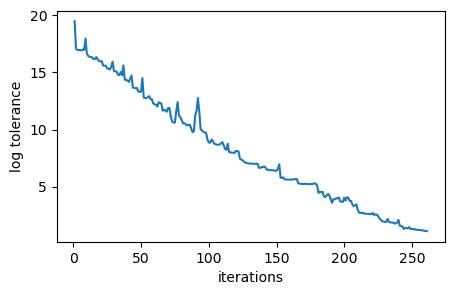

--> time = 0.19  min |  11.69 seconds
-> CGM converged?   True
-> Fit correctly?   True
!!!!  Sucess  !!!!
Building full visibility model...


In [30]:
f2d_AS209.fit(run_from_scratch = True, kernel_params = best_AS209, rtol = 1e-8)

In [52]:
Plot_AS209_2 = Plot(f2d_AS209, geom_AS209 )

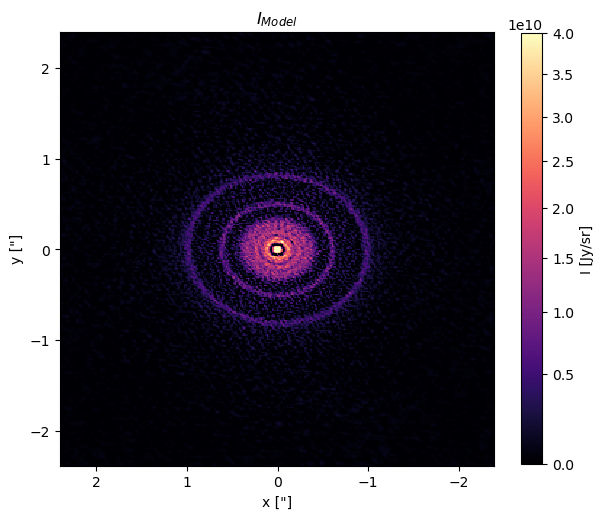

In [55]:
Plot_AS209_2.intensity(fig_size = 7, vmax = 4e10, gamma = 0.75)

	 Reverting to standard azimuthal averaging; will ignore `unit` argument.
Clean beam: 0.038216292858108 x 0.036224924027904 arcsec
Performing 1D Frank fit...


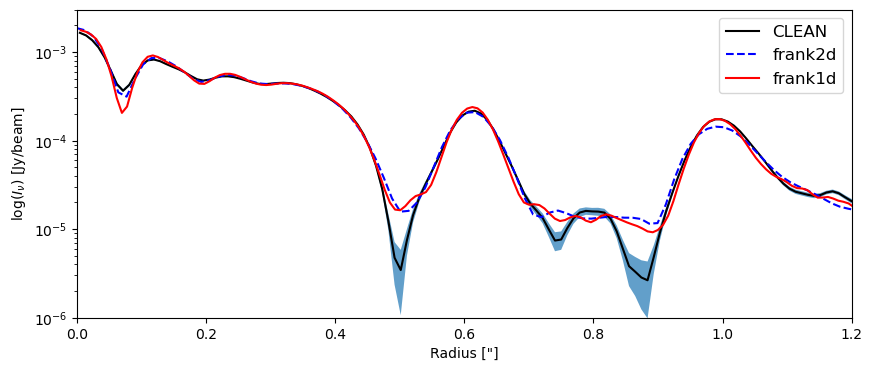

In [60]:
Plot_AS209_2.intensity_profile(clean = True, fits_file = fits_1mm_AS209)

Performing 1D Frank fit...


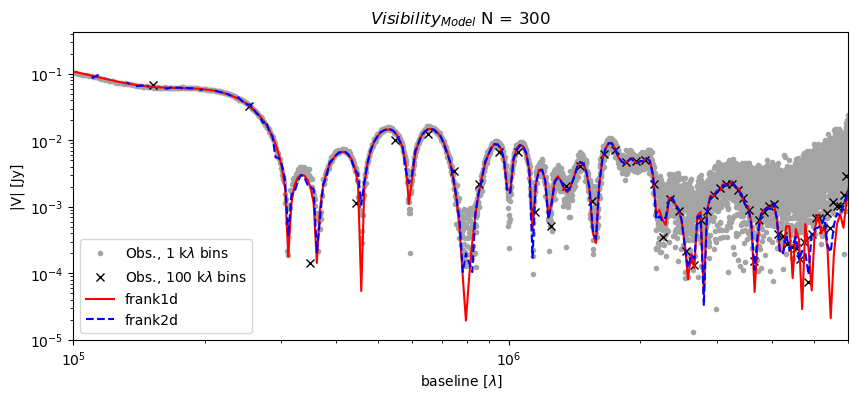

In [61]:
Plot_AS209_2.visibility_profile(input = uvtable_AS209, weighted = True, frank1d = True)